<h1><center>Laboratorio 5: La desperación de Mr. Lepin 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco e Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Felipe Muñoz
- Nombre de alumno 2: Antonia Landaeta


---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores. 
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [31]:
!uv add numpy pandas scikit-learn umap-learn plotly

Resolved 141 packages in 6ms
Audited 137 packages in 138ms


In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.base import BaseEstimator, TransformerMixin


def plot_dim_reductions(
    pca_proj: np.ndarray,
    tsne_proj: np.ndarray,
    umap_proj: np.ndarray,
    name: None | str = None,
    colors: None | np.ndarray = None,
) -> go.Figure:
    fig = make_subplots(rows=1, cols=3, subplot_titles=("PCA", "t-SNE", "UMAP"))

    for i, (proj, title) in enumerate(zip([pca_proj, tsne_proj, umap_proj], ["PCA", "t-SNE", "UMAP"], strict=True)):
        temp_fig = px.scatter(
            x=proj[:, 0],
            y=proj[:, 1],
            color=colors.astype(str) if colors is not None else None,
            title=title,
            # showlegend=(i == 0),
        )

        for trace in temp_fig.data:
            trace.showlegend = i == 0
            fig.add_trace(trace, row=1, col=i + 1)

    fig.update_layout(height=400, width=1200, title_text=name)
    return fig

In [248]:
import plotly.io as pio #para que aparezcan los gráficos en el repositorio

pio.renderers.default = "png"

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar Dataset

Mr. Lepin, en una nueva reunión, le cuenta a ud y su equipo que los resultados derivados del análisis exploratorio de datos presentaron una gran utilidad para la empresa y que tiene un gran entusiasmo por continuar trabajando con ustedes.
Es por esto, que Mr. Lepin les pide que cargue y visualicen algunas de las filas que componen el Dataset.
A continuación un extracto de lo parlamentado en la reunión:

    - Usted: Es un gran logro para nuestro equipo que usted haya encontrado excelente el EDA. ¿Qué tiene en mente ahora?
    - Mr. Lepin: Resulta que hace algún tiempo, mientras tomaba un mojito en una reunión de gerentes en Panamá, oí a un *chato* acerca de **LRMFP**, que es un modelo que permite personificar a los clientes a través de la fabricación de distintos atributos que describen a los clientes. Lo encontré es-tu-pendo ñatito. 
    - Usted: Ehh bueno. Investigaremos acerca de este modelo y veremos lo que podemos hacer.

Por ende, su siguiente tarea es calcular **LRMFP** sobre cada cliente y luego hacer un análisis de las características generadas. Para esto, el área de ventas les entrega un nuevo archivo llamado `retail_dataset.pickle`, quien posee los datos del DataFrame original limpios y listos para obtener las características solicitadas por Mr. Lepin.

In [76]:
df_retail = pd.read_pickle(
    "https://github.com/MDS7202/MDS7202/raw/refs/heads/main/recursos/2026-01/labs/lab6/retail_dataset.pickle"
)
df_retail = df_retail.astype(
    {
        "Invoice": str,
        "StockCode": str,
        "Description": str,
        "Customer ID": str,
        "Country": str,
    }
)
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1.2 Creación de nuevas Caracteristicas [2 Puntos] 

Como ya se les comentó, Mr. Lepin está interesado en obtener las características **LRMFP**, para esto les señala que estas características se construyen en base a las siguientes definiciones:

- **Length (L)**: Intervalo de tiempo, en días, entre la primera y la última visita del cliente. Mientras más grande sea el valor, más fiel es el cliente.

- **Recency (R)**: Indica hace cuánto tiempo el cliente realizó su última compra. Notar que para este caso, mientras más grande es el valor, menos interés posee el usuario para repetir una compra en uno de los locales.

- **Monetary (M)**: El término “monetario” se refiere a la cantidad media de dinero gastada por cada visita del cliente durante el período de observación y refleja la contribución del cliente a los ingresos de la empresa.

- **Frequency (F)**: Se refiere al número total de visitas del cliente durante el periodo de observación. Cuanto mayor sea la frecuencia, mayor será la fidelidad del cliente. 

- **Periodicity (P)**: Representa si los clientes visitan las tiendas con regularidad.

$$Periodicity(n)=std(IVT_1, ..., IVT_n)$$

&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Donde $IVT$ denota el tiempo entre visitas y n representa el número de valores de tiempo entre visitas de un cliente.
 

$$IVT_i=date\_diff(t_{i+1},t_i)$$

En base a las definiciones señaladas, diseñe una función que permita obtener las características **LRMFP** recibiendo un DataFrame como entrada. Para esto, no estará permitido el uso de iteradores; utilicen todas las herramientas que les ofrece `pandas` para realizar esto.

Una referencia que les puede ser útil es el [documento original](https://www.researchgate.net/publication/315979555_LRFMP_model_for_customer_segmentation_in_the_grocery_retail_industry_a_case_study) en donde se propone este método.

**<u>Formato</u> del Resultado Esperado:**

| Customer ID | Length | Recency | Frequency | Monetary | Periodicity |
|------------:|-------:|--------:|----------:|---------:|------------:|
|   12346.0   |    294 |      67 |        46 |   -64.68 |        37.0 |
|   12347.0   |     37 |       3 |        71 |  1323.32 |         0.0 |
|   12349.0   |    327 |      43 |       107 |  2646.99 |        78.0 |
|   12352.0   |     16 |      11 |        18 |   343.80 |         0.0 |
|   12356.0   |     44 |      16 |        84 |  3562.25 |        12.0 |

**Respuesta:**

In [78]:
def custom_features(dataframe_in: pd.DataFrame) -> pd.DataFrame:
    df = dataframe_in.copy()
    # --------------------------------------------------------------------
    # Se calcula Length
    fecha_min = df[["Customer ID", "InvoiceDate"]].groupby("Customer ID")["InvoiceDate"].min().reset_index()
    fecha_max = df[["Customer ID", "InvoiceDate"]].groupby("Customer ID")["InvoiceDate"].max().reset_index()

    # Se hace un merge en base a Customer ID, y se renombran las columnas de fecha para diferenciarlas
    length_df = fecha_max.merge(fecha_min, on="Customer ID", suffixes=("_max", "_min"))
    length_df["length"] = (length_df["InvoiceDate_max"] - length_df["InvoiceDate_min"]).dt.days

    # --------------------------------------------------------------------
    # Se calcula Recency
    # Rankear fechas por cliente, de mayor a menor
    df_sorted = df[["Customer ID", "InvoiceDate"]].copy()

    # Se rankean las fechas por cliente, de mayor a menor, usando el método dense para asignar rangos consecutivos
    df_sorted["rank"] = df_sorted.groupby("Customer ID")["InvoiceDate"].rank(method="dense", ascending=False)

    penultima_fecha = df_sorted[df_sorted["rank"] == 2].groupby("Customer ID")["InvoiceDate"].first().reset_index()

    # Se hace un merge en base a Customer ID, y se renombran las columnas de fecha para diferenciarlas
    df_recency = fecha_max.merge(penultima_fecha, on="Customer ID", suffixes=("_max", "_penultima"))
    df_recency["recency"] = (df_recency["InvoiceDate_max"] - df_recency["InvoiceDate_penultima"]).dt.days

    # --------------------------------------------------------------------
    # Se calcula Monetary
    df_monetary = df.copy()

    # Se calcula el ingreso por cada fila multiplicando la cantidad por el precio unitario
    df_monetary["income"] = df_monetary["Quantity"] * df_monetary["Price"]

    # Se agrupa por cuanto gasto cada cliente por factura
    df_monetary_grouped_invoice = df_monetary.groupby(["Customer ID", "Invoice"])["income"].sum().reset_index()

    # Se calcula el promedio de cuanto gasto cada cliente por factura
    df_monetary_grouped_mean = df_monetary_grouped_invoice.groupby("Customer ID")["income"].mean().reset_index()

    # --------------------------------------------------------------------
    # Se calcula Frequency
    # Se agrupa por cliente, y se cuentan las facturas únicas para cada cliente
    df_frequency = df.groupby(["Customer ID"])["Invoice"].nunique().reset_index(name="frequency")

    # --------------------------------------------------------------------
    # Se calcula Periodicity
    df_sorted_sort = (
        df_sorted.drop_duplicates(subset=["Customer ID", "InvoiceDate"])
        .sort_values(["Customer ID", "rank"])
        .reset_index(drop=True)
    )

    # Se usa shift dentro del grupo para obtener la fecha anterior
    df_sorted_sort["prev_date"] = df_sorted_sort.groupby("Customer ID")["InvoiceDate"].shift(
        -1
    )  # Se obtiene la fecha anterior con shift(-1) (Se ordeno el ranking de manera descendente)

    # Se calcula el IVT
    df_sorted_sort["IVT"] = (df_sorted_sort["InvoiceDate"] - df_sorted_sort["prev_date"]).dt.days.abs()

    df_periodicity = (
        df_sorted_sort.groupby("Customer ID")["IVT"].std().fillna(0).reset_index(name="periodicity")
    )  # Verificar el fillna(0) para clientes que visitan una sola vez.

    # Resultado final
    result = (
        length_df[["Customer ID", "length"]]
        .merge(df_recency[["Customer ID", "recency"]], on="Customer ID")
        .merge(df_monetary_grouped_mean.rename(columns={"income": "monetary"}), on="Customer ID")
        .merge(df_frequency, on="Customer ID")
        .merge(df_periodicity, on="Customer ID")
    )
    return result

In [79]:
custom_features(df_retail)

,Customer ID,length,recency,monetary,frequency,periodicity
0,12346.0,196,118,33.896364,11,36.659999
1,12347.0,37,37,661.660000,2,0.000000
2,12349.0,181,162,890.380000,3,101.823376
3,12352.0,16,16,171.900000,2,0.000000
4,12356.0,44,12,1186.766667,3,13.435029
...,...,...,...,...,...,...
2892,18276.0,336,39,264.132000,5,37.349699
2893,18277.0,97,19,267.417500,4,40.673497
2894,18283.0,275,0,103.228333,6,61.832839
2895,18286.0,247,247,648.215000,2,0.000000


## 1.3 Pipelines 👷

Finalmente *Mr. Lepin* le pregunta si sería posible realizar un pipeline para realizar una segmentación de los clientes con los nuevos datos generados, a lo que usted responde que **sí** y propone la utilización de k-means para la segmentación.

A continuación siga los pasos requeridos para obtener la segmentación de clientes.

### 1.3.1 Estandarizar Caracteristicas [0.5 puntos]

Construya una clase llamada ``MinMax()`` utilizando ``BaseEstimator`` y ``TransformerMixin`` para realizar una transformación de cada una de las columnas de un DataFrame utilizando ``ColumnTransformer()`` más tarde (tome como referencia el siguiente [enlace](https://sklearn-template.readthedocs.io/en/latest/user_guide.html#transformer)).


 Para esto considere que Min-Max escaler queda dada por la ecuación:

$$MinMax = \dfrac{x-min(x)}{max(x) - min(x)}$$

Con esto buscamos que los valores que componen a las columnas se muevan en el rango de valores $[0, 1]$.

**Respuesta:**

In [80]:
class MinMax(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        return self

    def transform(self, X):
        X_scaled = (X - self.min_) / (self.max_ - self.min_)
        return X_scaled

### 1.3.2 Pipelines de Proyecciones [0.5 puntos]

Para comparar técnicas de reducción de dimensionalidad, realice **tres pipelines** distintos sobre los datos **LRMFP** usando los siguientes métodos:
- **PCA**
- **t-SNE**
- **UMAP**

Para cada pipeline, siga estos pasos:
1. Obtenga las características **LRMFP** desde el DataFrame `retail_dataset.pickle` utilizando la función ``custom_features`` creada anteriormente, junto a ``FunctionTransformer()``. Considere esto como el primer paso de su pipeline.
2. En segundo lugar, usando ``ColumnTransformer()``, aplique el MinMax scaler creado por usted sobre todas las columnas generadas en el paso anterior.
3. Finalmente, aplique el método de reducción de dimensionalidad correspondiente (PCA, t-SNE o UMAP) para obtener las 2 componentes más relevantes.

A continuación, grafique las proyecciones obtenidas de las tres técnicas en una sola figura comparativa.

**Respuesta:**

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from umap import UMAP

features = ["length", "recency", "monetary", "frequency", "periodicity"]

# Pipeline PCA
pipeline_pca = Pipeline(
    [
        ("transformer", FunctionTransformer(custom_features)),
        (
            "scaler",
            ColumnTransformer(transformers=[("minmax", MinMax(), features)]),
        ),  # Se escala sobre las features calculadas y no sobre el ID del cliente
        ("pca", PCA(n_components=2)),
    ]
)

# Pipeline TSNE
pipeline_tsne = Pipeline(
    [
        ("transformer", FunctionTransformer(custom_features)),
        ("scaler", ColumnTransformer(transformers=[("minmax", MinMax(), features)])),
        ("tsne", TSNE(n_components=2, random_state=7)),
    ]
)

# . Pipeline UMAP
pipeline_umap = Pipeline(
    [
        ("transformer", FunctionTransformer(custom_features)),
        ("scaler", ColumnTransformer(transformers=[("minmax", MinMax(), features)])),
        ("umap", UMAP(n_components=2, random_state=7)),
    ]
)

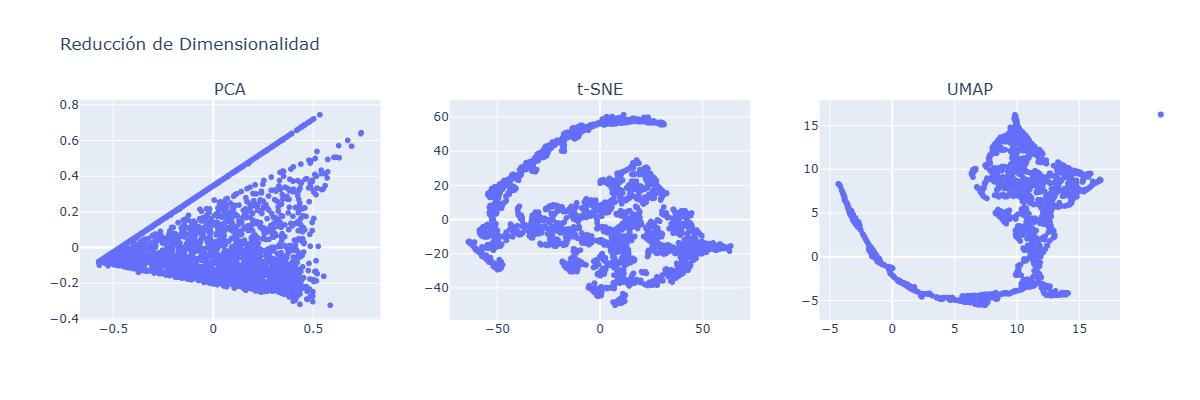

In [249]:
# Utilice este código para ejecutar las pipelines y graficar.

pca_proj = pipeline_pca.fit_transform(df_retail)
tsne_proj = pipeline_tsne.fit_transform(df_retail)
umap_proj = pipeline_umap.fit_transform(df_retail)

fig = plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="Reducción de Dimensionalidad", colors=None)
fig.show(renderer="png")

### 1.3.3 Análisis de los Loadings de PCA [0.5 puntos]
Antes de continuar con la etapa de clustering, analice los *loadings* (pesos o coeficientes) de las componentes principales obtenidas con PCA. 

Utilice el siguiente tutorial para visualizarlos: https://plotly.com/python/pca-visualization/

- Calcule y reporte los *loadings* de las dos primeras componentes principales.
- Interprete qué características (**LRMFP**) son más relevantes en cada componente.
- Visualice los *loadings* usando un gráfico de barras para cada componente.



In [84]:
# accedemos al objeto PCA entrenado
pca_paso = pipeline_pca.named_steps["pca"]

# extraemos los loadings
loadings = pca_paso.components_.T

# reporte de los loadings
loadings_df = pd.DataFrame(data=loadings, columns=["PC1", "PC2"], index=features)
print(loadings_df)

                  PC1       PC2
length       0.957545 -0.160341
recency      0.181241  0.979230
monetary     0.002758 -0.021146
frequency    0.047047 -0.081026
periodicity  0.219176 -0.091583


**Interpretación de las componentes**
>

> Las características con signo positivo indican que están correlacionadas positivamente con sus componentes principales, en contraste con las negativas que tienen una relación inversa. Para la componente principal PC1, la característica más relevante es "length" altamente correlacionada positiva, seguido en menor medida "periodicity" y "frequency", ambas también positivas. Para la componente principla PC2, la más relevante es "recency", altamente correlacionada positiva. 

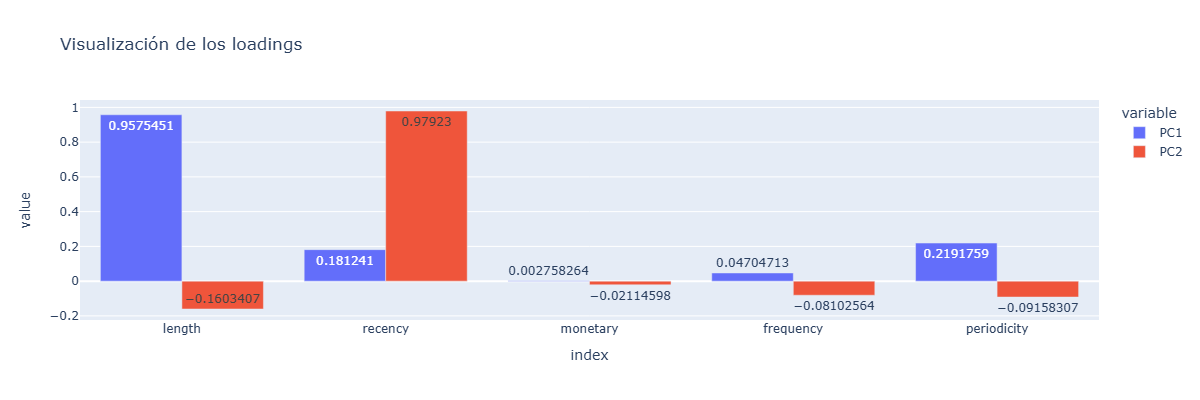

In [250]:
# visualización de los loadings
fig_loadings = px.bar(loadings_df, barmode="group", title="Visualización de los loadings", text_auto=True, width=1200, height=400)
fig_loadings.show(renderer="png")

### Preguntas sobre loadings:

- ¿Qué son los loadings de PCA?

> Respuesta: Los loadings son los pesos que define la contribución de las variables originales a las componentes principales (forma reducida de los datos).

- ¿Qué información relevante obtiene sobre la estructura de los datos a partir de los *loadings* de PCA?

> Respuesta: Los loadings revelan el nivel de correlación entre los datos originales mediante la agrupación de los atributos en el espacio reducido. Toman valores entre [-1,1]. Si tienen un valor absoluto cercano a 1, indica que la variable contribuye más en las componentes principales.

- ¿Existe alguna relación interesante entre las direcciones de las variables?

> Respuesta: Si las variables comparten la misma dirección, indica que están capturando la misma información, por ende están altamente correlacionadas, agregando redundancia.

## 1.4 Clustering

### 1.4.1 Método del Codo [0.5 puntos]

Utilizando la clase creada para escalamiento, aplique el método del codo para visualizar cuál es el número de clusters que mejor se ajustan a los datos. Realice esto utilizando el algoritmo K-means dentro de un pipeline para un $k \in [1,20]$, donde k representa el número de clusters del k-means. Para la realización de esta sección y la próxima (1.4.2), considere los mismos pasos utilizados para el t-SNE, pero **permutando el algoritmo de reducción de dimensionalidad por k-means.**

**Respuesta:**

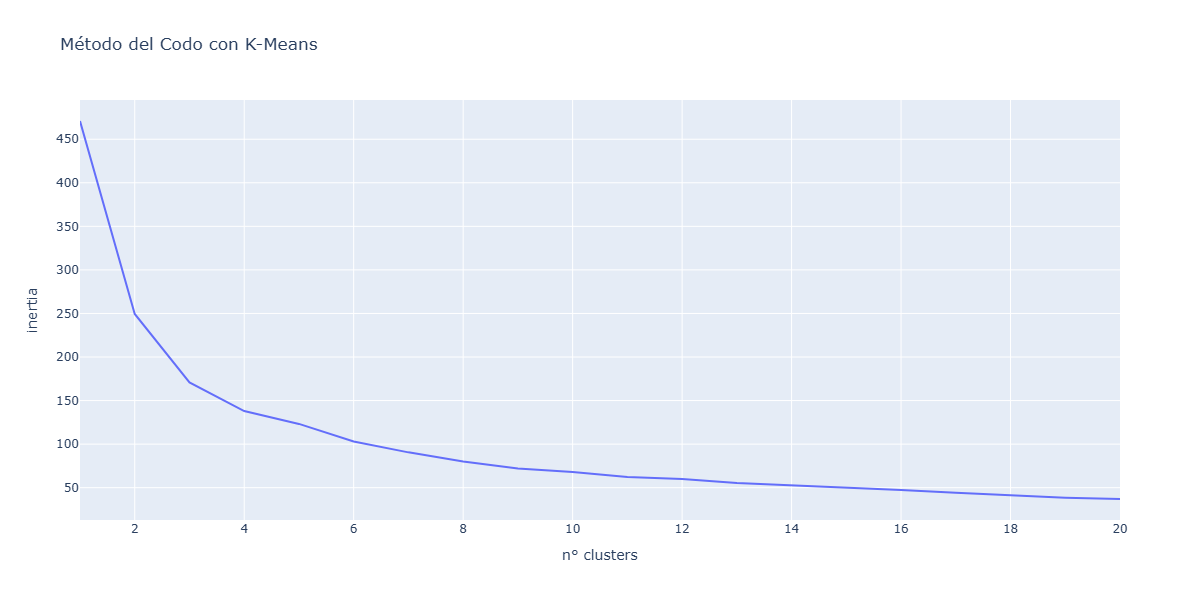

In [253]:
from sklearn.cluster import KMeans  # noqa: F401

# Pipeline K-means
pipeline_kmeans = Pipeline(
    [
        ("transformer", FunctionTransformer(custom_features)),
        (
            "scaler",
            ColumnTransformer(transformers=[("minmax", MinMax(), features)]),
        ),  # Se escala sobre las features calculadas y no sobre el ID del cliente
        (
            "kmeans",
            KMeans(n_clusters=2, random_state=7),
        ),  # Entrenar el modelo K-Means con un número específico de clusters y una semilla para reproducibilidad
    ]
)

kmeans_proj = pipeline_kmeans.fit_transform(df_retail)

# Se reutiliza el pipeline cambiando n_clusters en cada iteración
inertias = []

for i in range(1, 21):
    pipeline_kmeans.set_params(
        kmeans__n_clusters=i
    )  # Se usa set_params para cambiar el número de clusters en el pipeline
    pipeline_kmeans.fit(df_retail)
    inertias.append([i, pipeline_kmeans.named_steps["kmeans"].inertia_])

inertias = pd.DataFrame(inertias, columns=["n° clusters", "inertia"])

# Gráfico del método del codo
px.line(
    inertias,
    x="n° clusters",
    y="inertia",
    title="Método del Codo con K-Means",
    height=600,
    width=1200,
)

### Preguntas Método del Codo

- A través del gráfico obtenido, comente y justifique qué valor de k escogería para realizar el k-means.
> Respuesta: Según el gráfico de Inercia, escogemos el valor óptimo $k=4$ debido a que para 5 o más clusters no minimizan significativamente la inercia.

- Le fue útil el método del codo para encontrar el número de clusters?

> Respuesta: Sí

- Si no fue así, ¿qué otros métodos podría haber usado para encontrar un número óptimo de clusters?

> Respuesta: Hay otro método para los algoritmos de agrupamiento llamado Sillhouette Score, que mide cuan similiar es un objeto a su propio cúmulo en comparación de los otros.

### 1.4.2 Segmentación de Clientes con K-Means 🎁 [1 punto]

Por último, Mr. Lepin, impaciente de no entender lo que usted intenta explicarle, le solicita que por favor muestre algún resultado "visual y entendible" de los grupos encontrados.

En base a la elección de k realizada en la sección anterior, utilice este valor escogido y entrene un modelo de K-means utilizando el mismo pipeline de scikit-learn utilizado anteriormente.

Una vez ajustado los datos, genere una tabla con los promedios (o medianas) para cada uno de los atributos, agrupando estos por el clúster que pertenecen.

Finalmente, construya un heatmap de las características promedio de cada cluster para visualizar y comparar los perfiles de los grupos.

**Estadísticas de Referencia para K=6:**

Ud. debe calcularlas - Varían de ejecución en ejecución.


|         | Length  | Recency   | Frequency | Monetary | Periodicity |       |
|---------|---------|-----------|----------|-------------|-------|-------|
| Cluster |         |           |          |             |       |       |
|    0    |   258.8 |      45.2 |     76.1 |      1107.7 | 107.6 |   449 |
|    1    |    76.1 |     217.6 |     45.5 |       791.7 |  14.1 |   466 |
|    2    |   368.5 |       4.8 |   2715.0 |    226621.6 |   4.2 |     4 |
|    3    |    85.3 |      45.7 |     65.8 |      1047.0 |  10.5 |   987 |
|    4    |   347.2 |      15.9 |   1658.0 |     35829.3 |   8.0 |    25 |
|    5    |   298.0 |      29.8 |    183.8 |      3639.9 |  32.0 |  1188 |

In [50]:
# Aquí calcule K-Means

# Pipeline K-means - 4 clusters es lo óptimo
pipeline_kmeans = Pipeline(
    [
        ("transformer", FunctionTransformer(custom_features)),
        (
            "scaler",
            ColumnTransformer(transformers=[("minmax", MinMax(), features)]),
        ),  # Se escala sobre las features calculadas y no sobre el ID del cliente
        (
            "kmeans",
            KMeans(n_clusters=4, random_state=7),
        ),  # Entrenar el modelo K-Means con un número específico de clusters y una semilla para reproducibilidad
    ]
)

kmeans_proj = pipeline_kmeans.fit_transform(df_retail)

In [51]:
# Fit del pipeline
pipeline_kmeans.fit(df_retail)

# Extraer las labels de cluster
kmeans_labels = pipeline_kmeans.named_steps["kmeans"].labels_

# Obtener el DataFrame LRMFP junto a los clusters que pertenece cada cliente
df_clusters = custom_features(df_retail)
df_clusters["cluster"] = kmeans_labels
display(df_clusters)

,Customer ID,length,recency,monetary,frequency,periodicity,cluster
0,12346.0,196,118,33.896364,11,36.659999,1
1,12347.0,37,37,661.660000,2,0.000000,3
2,12349.0,181,162,890.380000,3,101.823376,0
3,12352.0,16,16,171.900000,2,0.000000,3
4,12356.0,44,12,1186.766667,3,13.435029,3
...,...,...,...,...,...,...,...
2892,18276.0,336,39,264.132000,5,37.349699,2
2893,18277.0,97,19,267.417500,4,40.673497,3
2894,18283.0,275,0,103.228333,6,61.832839,2
2895,18286.0,247,247,648.215000,2,0.000000,0


In [52]:
# Se obtiene el promedio de cada uno de los atributos agrupados por cluster
promedio_cluster = df_clusters.groupby("cluster")[features].mean().round(3)

promedio_cluster

,length,recency,monetary,frequency,periodicity
cluster,,,,,
0,270.874,221.131,350.947,2.860,44.829
1,172.980,73.516,362.375,4.245,32.334
2,318.771,30.786,424.194,11.673,44.388
3,46.758,29.068,395.939,2.899,6.695


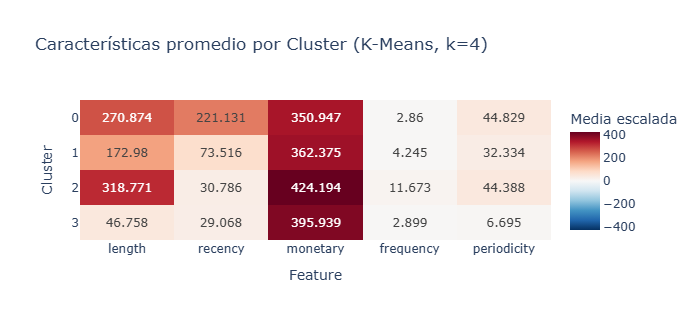

In [254]:
fig = px.imshow(
    promedio_cluster,
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0,
    text_auto=True,
    aspect="auto",
    title="Características promedio por Cluster (K-Means, k=4)",
    labels={"x": "Feature", "y": "Cluster", "color": "Media escalada"},
    height=320,
)
fig.show(renderer="png")

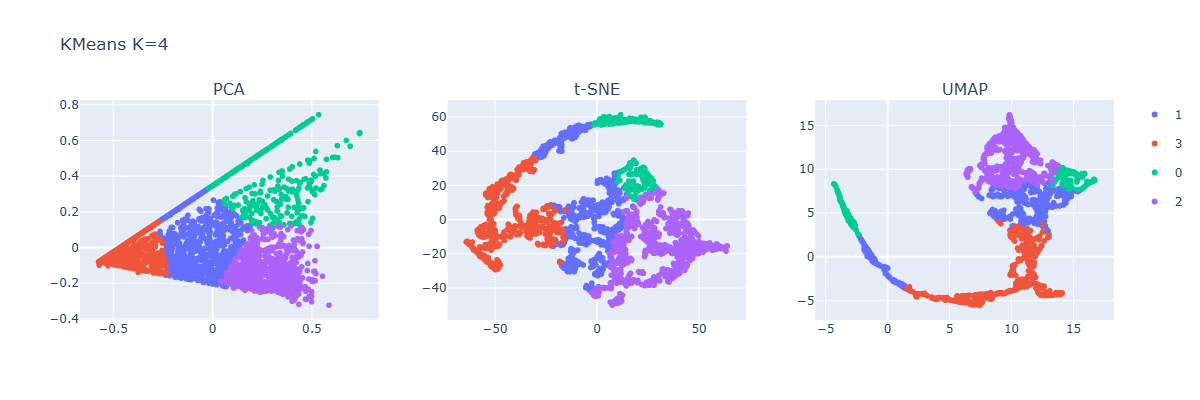

In [255]:
# Utilice la siguiente función para graficar k-means. kmeans_labels = clusters obtenidos por k-means.
plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="KMeans K=4", colors=kmeans_labels)

### Preguntas sobre K-Means: 

- ¿Se separaron bien los distintos clusters en cada visualización? 

> Respuesta: No realmente

- ¿Es posible observar agrupaciones coherentes?

> Respuesta: No se identifica ninguna. No agrupa en una clase las "colas" de los 3 casos.

- ¿Quedarían mejor más o menos clusters?

> Respuesta: Probamos para $k=2$ y $k=6$ y no hay mejoras. Esto se puede deber que lo datos no cumplen con la suposición de convexidad ni de tamaño similar que supone K-Means.

- ¿K-Means, dada la forma de las proyecciones, será el mejor método para clusterizar este dataset?¿Habrá algún otro mejor?

> Respuesta: No lo es. Una alternativa podría ser DBSCAN pues se adaptaria mejor a la forma de la data con su enfoque de densidad al no favorecer eñ modelo a una forma concreta.

Y por último:

- Nombre a cada uno de los clusters según el comportamiento de sus miembros (ej. "C1: Compran poco pero con gran valor...") - Si es necesario, ajuste el número de clusters antes de responder.

> Respuestas: Se ejecutó k-means para $k=4$ clusters. En concreto:

> - C1: Son clientes muy fieles que repiten sus compras en los locales y que se caracterizan por que gastar mucho, pero no son fidedignos ni periódicos.
> - C2: Son clientes muy fieles que gastan mucho y en menor medida repiten sus compras en los locales, en comparación con C1.
> - C3: Son clientes muy fieles que gastan mucho, pero no frecuentan mucho ni visitan con tanta regularidad, ni repiten sus compras en los locales.
> - C4: Son clientes que gastan mucho, pero no frecuentan, no son fieles, ni fidedignos ni visitan con tanra regularidad. Se podría decir que son clientes que prueban una vez y no vuelven.

Justifique su respuesta y no decepcione a Mr. Lepin.

## 1.5 Detección de Anomalías con DBSCAN [1 punto]
En esta sección, utilizará el algoritmo DBSCAN para identificar posibles anomalías (outliers) en los clientes del retail.

- Puede aplicar DBSCAN sobre las características originales escaladas (**LRMFP**) o sobre alguna de las proyecciones 2D (PCA, t-SNE o UMAP). Justifique su elección en las preguntas al final de la sección.
- Visualice los resultados usando `plot_dim_reductions`, mostrando los clusters y resaltando los outliers (label = -1) en las tres proyecciones (PCA, t-SNE, UMAP).

In [256]:
from sklearn.cluster import DBSCAN  # noqa: F401

# Pipeline DBSCAN
pipeline_dbscan = Pipeline(
    [
        ("transformer", FunctionTransformer(custom_features)),
        (
            "scaler",
            ColumnTransformer(transformers=[("minmax", MinMax(), features)]),
        ),  # Se escala sobre las features calculadas y no sobre el ID del cliente
        (
            "dbscan",
            DBSCAN(eps=0.04, min_samples=5), # eps = 0.04 es el óptimo
        ),  # se aplica dbscan sobre los datos
    ]
)

# Fit del pipeline
pipeline_dbscan.fit(df_retail)

# Extraer las labels de cluster
dbscan_labels = pipeline_dbscan.named_steps["dbscan"].labels_

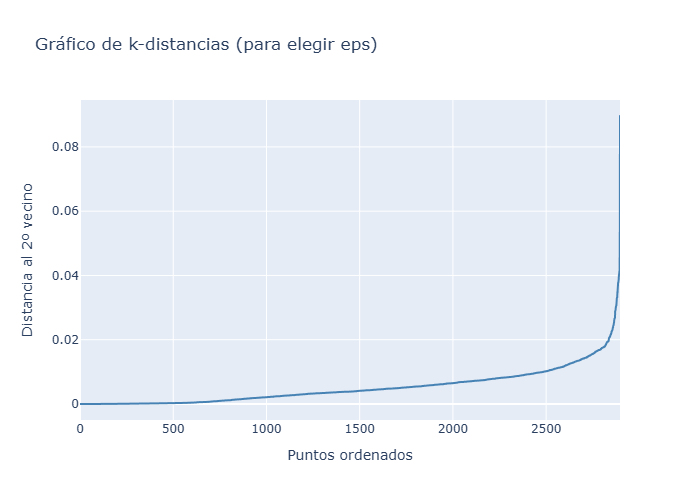

In [257]:
# Método del codo para escoger eps óptimo
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5).fit(pca_proj)
distances, indices = neighbors.kneighbors(pca_proj)
distances = np.sort(distances[:, 1])

px.line(
    x=range(len(distances)),
    y=distances,
    labels={"x": "Puntos ordenados", "y": "Distancia al 2º vecino"},
    title="Gráfico de k-distancias (para elegir eps)",
).update_traces(line_color="steelblue")

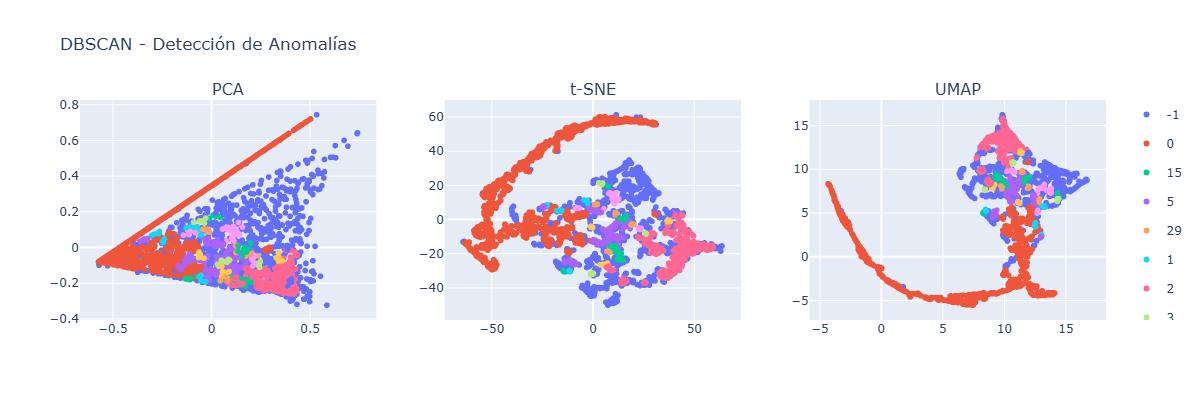

In [258]:
# Utilice este código para graficar. dbscan_labels = clusters/outliers obtenidos por DBSCAN.
fig_dbscan = plot_dim_reductions(
    pca_proj,
    tsne_proj,
    umap_proj,
    name="DBSCAN - Detección de Anomalías",
    colors=dbscan_labels,  # noqa: F821
)
fig_dbscan.show(renderer="png")

### Preguntas sobre DBSCAN


1. ¿Por qué decidiste usar los datos originales completos o las proyecciones para aplicar DBSCAN? ¿Por qué no usaste la otra opción?

> Respuesta: Decidimos usar los datos reducidos con el propósito de poder visualizar los clusters en 2D.

2. ¿Cómo elegiste los parámetros de DBSCAN (`eps`, `min_samples`)? ¿Probaste diferentes valores? ¿Cómo afectó esto los resultados?

> Respuesta: En un principio se ocuparon los valores default que ya venía del modelo. Luego probamos en achicar y agrandar el radio y el sampleo para observar algún cambio. En particular, para $eps =0.1$ se observan pocos outliers ubicados en las fronteras de las figuras, mientras que para $eps = 0.02$ aparecen en mayor proporción los outliers que representan la masa principal en los gráficos de detección de anomalías. Tras determinar el eps óptimo (0.04) mediante el método del codo de k-distancias, se indentifican múltiples clusters con label 0 siendo dominante y los outliers con label -1 distribuidos y dispersos en la frontera de las figuras.

3. ¿Tienen sentido los outliers encontrados según el contexto del negocio? ¿Qué interpretación le das a estos clientes? Analiza los datos con pandas si es necesario.

> Respuesta: Todo dependerá del radio que se defina. Al menos para el caso $eps = 0.04$ los outliers se encuentran dispersos en las fronteras de las aglomeraciones principales. Estos se pueden interpretar clientes con comportamiento de compra muy erraticos que no siguen una regla fija para agruparlos dentro de un grupo establecido de clientes.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por correo, Discord o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>